Text(0.5, 1.0, 'Random Classification Data with 2 classes')

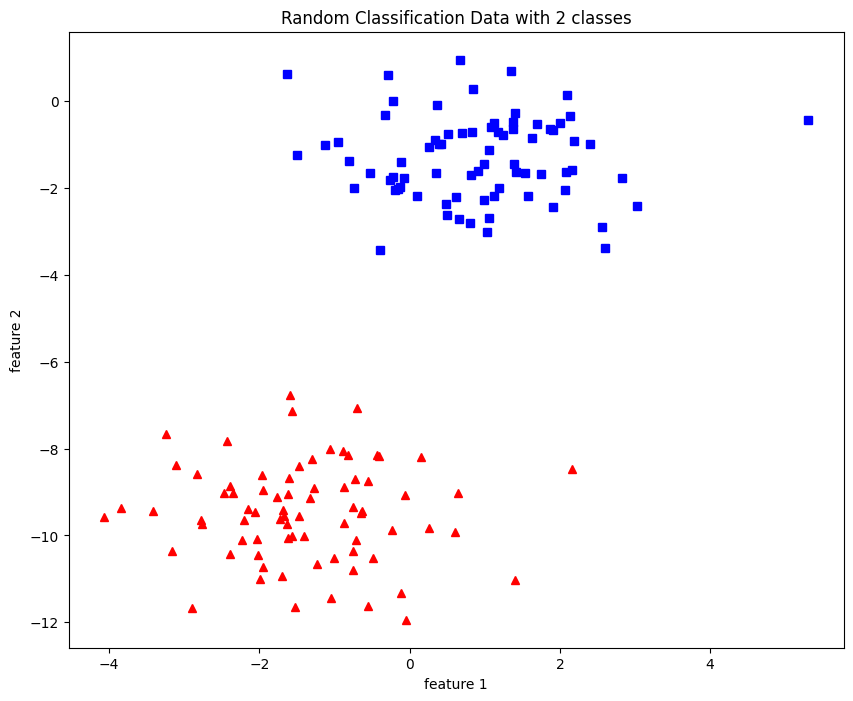

In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_blobs (n_samples=150, n_features=2,
 centers=2, cluster_std=1.05,
random_state=2)
#Plotting
fig = plt.figure(figsize=(10,8))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')

In [2]:
def acti_func(z):
    return 1 if z > 0 else 0

In [3]:
import numpy as np

def perceptron(X, y, lr, epochs):
    """
    X --> Inputs.
    y --> Labels/target.
    lr --> Learning rate.
    epochs --> Number of iterations.
    m -> Number of training examples.
    n -> Number of features.
    """
    m, n = X.shape

    # Initializing parameters (theta) to zeros.
    # +1 in n+1 for the bias term.
    w = np.zeros((n + 1, 1))

    # List to store the number of misclassified examples at every iteration.
    n_miss_list = []

    # Training loop.
    for epoch in range(epochs):
        n_miss = 0  # Variable to store the number of misclassified examples.

        # Looping over every example.
        for idx, x_i in enumerate(X):
            # Inserting 1 for bias, X0 = 1.
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Calculating prediction/hypothesis.
            y_hat = acti_func(np.dot(x_i.T, w))

            # Updating if the example is misclassified.
            if (np.squeeze(y_hat) - y[idx]) != 0:
                w += lr * (y[idx] - y_hat) * x_i  # Weight update rule
                n_miss += 1  # Increment misclassification count

        # Appending the number of misclassified examples at every iteration.
        n_miss_list.append(n_miss)

    return w, n_miss_list

In [4]:
lr = 0.1
epochs = 10
w, n_miss_list = perceptron(X, y, lr, epochs)

print("Final weights:\n", w)
print("Number of misclassified examples per epoch:\n", n_miss_list)

Final weights:
 [[1.        ]
 [0.14885954]
 [0.16938433]]
Number of misclassified examples per epoch:
 [14, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [5]:
def plot_decision_boundary(X, w):
    # X --> Inputs (features)
    # w --> Parameters (weights)

    # The Line is y=mx+c
    # So, Equate mx+c = w0.X0 + w1.X1 + w2.X2
    # Solving we find m and c

    x1 = np.array([min(X[:, 0]), max(X[:, 0])])
    m = -w[1] / w[2]
    c = -w[0] / w[2]
    x2 = m * x1 + c

    # Plotting
    plt.plot(x1, x2, 'r-', label="Decision Boundary")

    # Separate two clusters
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='b', marker='o', label="Cluster 0")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='r', marker='^', label="Cluster 1")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.title("Decision Boundary of Perceptron")
    plt.show()

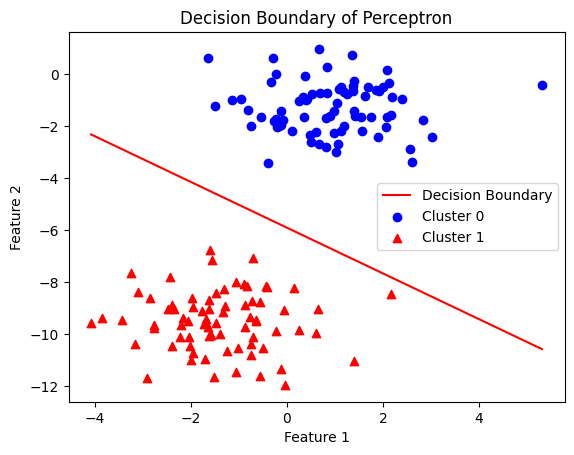

In [6]:
plot_decision_boundary(X, w)

**Exercice 2**

In [7]:
# Definition et mise à jour des fonctions:

from sklearn.model_selection import train_test_split

def generate_dataset(sigma1_sq, sigma2_sq):
    """
    Cette fonction génère un jeu de données à deux classes (-1 et 0).
    sigma1_sq et sigma2_sq représentent les variances des deux classes.
    """

    # Calcul des écarts-types à partir des variances fournies
    sigma1 = np.sqrt(sigma1_sq)
    sigma2 = np.sqrt(sigma2_sq)

    # Définir les moyennes pour chaque classe
    mu1 = np.array([-1, 0]) # Moyenne de la classe -1
    mu2 = np.array([1, 0]) # Moyenne de la classe 0

    # Générer les données pour chaque classe avec une distribution normale
    X1 = np.random.normal(mu1, sigma1, (125, 2))  # 125 points pour la classe -1
    X2 = np.random.normal(mu2, sigma2, (125, 2))  # 125 points pour la classe 0

    # Combiner les points de données des deux classes
    X = np.vstack((X1, X2))  # Concaténer les deux matrices de données
    y = np.hstack((-1 * np.ones(125), np.zeros(125)))  # Labels (-1 et 0)

    # Mélanger les données de manière aléatoire
    indices = np.random.permutation(len(y))  # Générer des indices aléatoires
    X, y = X[indices], y[indices]  # Appliquer les indices pour mélanger X et y

    # Diviser le dataset en ensembles d'entraînement (80%) et de test (20%)
    return train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


# Mettre a jour la fonction d'activation pour convenir les classes 0 et -1
def acti_func(z):
    return 0 if z > 0 else -1

def perceptron(X, y, lr, epochs):
    """
    X --> Features
    y --> Labels/target (-1 ou 0)
    lr --> Learning rate (taux d'apprentissage)
    epochs --> Nombre d'itérations d'entraînement
    """
    m, n = X.shape # m = nombre d'exemples, n = nombre de caractéristiques

    # Initialisation des poids (y compris le biais)
    w = np.zeros((n + 1, 1)) # Le biais est ajouté à la fin des poids

    # Liste pour stocker le nombre de points mal classés à chaque époque
    n_miss_list = []

    # Boucle d'entraînement
    for epoch in range(epochs):
        n_miss = 0  # Initialisation du nombre de points mal classés pour cette époque

        for idx, x_i in enumerate(X):
            # Ajout du biais X0 = 1
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Calcul de la prédiction en appliquant la fonction d'activation
            y_hat = acti_func(np.dot(x_i.T, w))

            # Mise à jour si erreur de classification est détectée
            if y_hat != y[idx]:
                correction = lr * (y[idx] - y_hat) # Calcul de la correction
                w += correction * x_i  # Mise à jour des poids
                n_miss += 1

        # Stocker le nombre d'erreurs pour cette époque
        n_miss_list.append(n_miss)

    return w, n_miss_list

def calculate_accuracy(X_test, y_test, w):
    """
    X_test --> Features de test.
    y_test --> Labels de test.
    w --> Poids entraînés du perceptron.
    """
    correct_predictions = 0
    total_samples = len(y_test)

    for idx, x_i in enumerate(X_test):
        # Ajout du biais X0 = 1
        x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

        # Calcul de la prédiction
        y_pred = acti_func(np.dot(x_i.T, w))

        # Comparaison avec le label réel
        if y_pred == y_test[idx]:
            correct_predictions += 1

    # Calcul de l'accuracy
    accuracy = correct_predictions / total_samples
    return accuracy


def plot_decision_boundary(X, y, w):
    # X --> Inputs (features)
    # y --> Labels (-1 ou 0).
    # w --> Parameters (weights)

    # Vérification pour éviter la division par zéro
    if w[2] == 0:
        print("Impossible de tracer la frontière de décision : w[2] = 0.")
        return

    # Calcul de la pente (m) et de l'ordonnée à l'origine (c) de la droite de décision
    x1 = np.array([min(X[:, 0]), max(X[:, 0])]) # Plage des valeurs de x1
    m = -w[1] / w[2]
    c = -w[0] / w[2]
    x2 = m * x1 + c # Calcul de la deuxième dimension (x2) en fonction de x1

    # Tracer la limite de décision
    plt.plot(x1, x2, 'r-', label="Decision Boundary")

    # Tracer les points de chaque classe
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='b', marker='o', label="Classe 0")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='r', marker='^', label="Classe -1")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.title("Decision Boundary of Perceptron")

    plt.show()

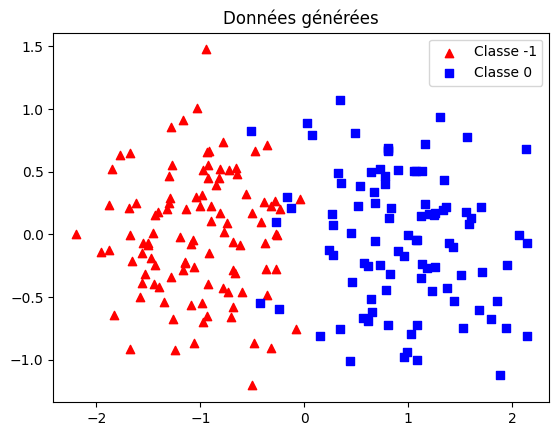

In [14]:
# Experience 1

# Générer un dataset pour sigma1^2 = sigma2^2 = 0.25
X_train, X_test, y_train, y_test = generate_dataset(0.25, 0.25)

# Visualisation des données
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], c='red', marker='^', label='Classe -1')
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', marker='s', label='Classe 0')
plt.legend()
plt.title("Données générées")

plt.show()

In [9]:
# Entraînement du Perceptron
w, errors = perceptron(X_train, y_train, lr=0.1, epochs=10)

print("Poids finaux :", w)
print("Erreurs par époque :", errors)

Poids finaux : [[0.1       ]
 [0.22926246]
 [0.02201322]]
Erreurs par époque : [9, 4, 6, 6, 2, 4, 4, 4, 4, 6]


In [10]:
# Calcul de l'accuracy sur l'ensemble de test
accuracy = calculate_accuracy(X_test, y_test, w)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


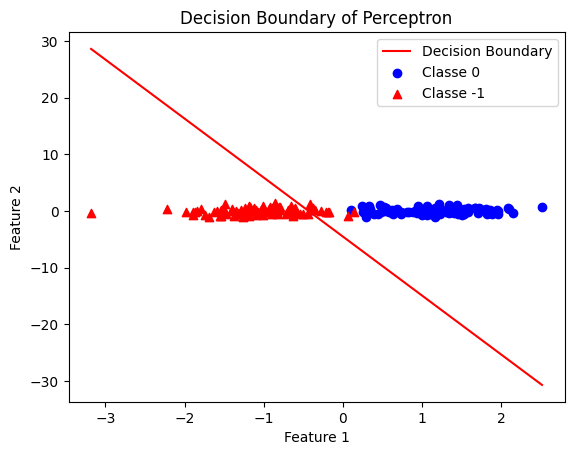

In [11]:
# Limite de decision
plot_decision_boundary(X_train, y_train, w)

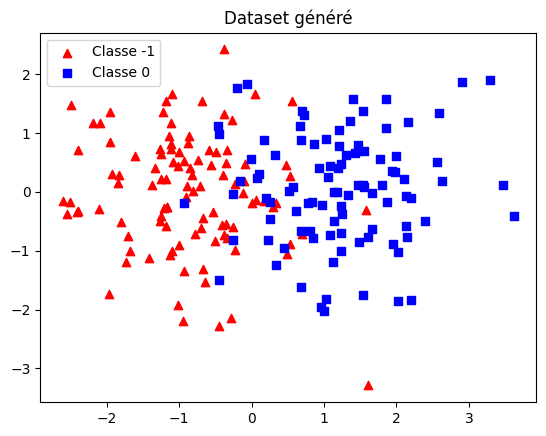

In [15]:
# Experience 2

# Générer un dataset pour sigma1^2 = sigma2^2 = 0.75
X_train, X_test, y_train, y_test = generate_dataset(0.75, 0.75)

# Visualisation des données
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], c='red', marker='^', label='Classe -1')
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='blue', marker='s', label='Classe 0')
plt.legend()
plt.title("Dataset généré")

plt.show()

In [16]:
# Entraînement du Perceptron
w, errors = perceptron(X_train, y_train, lr=0.1, epochs=10)

print("Poids finaux :", w)
print("Erreurs par époque :", errors)

Poids finaux : [[0.        ]
 [0.1853448 ]
 [0.04628153]]
Erreurs par époque : [32, 30, 33, 33, 34, 36, 36, 34, 34, 32]


In [17]:
# Calcul de l'accuracy sur l'ensemble de test
accuracy = calculate_accuracy(X_test, y_test, w)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 92.00%


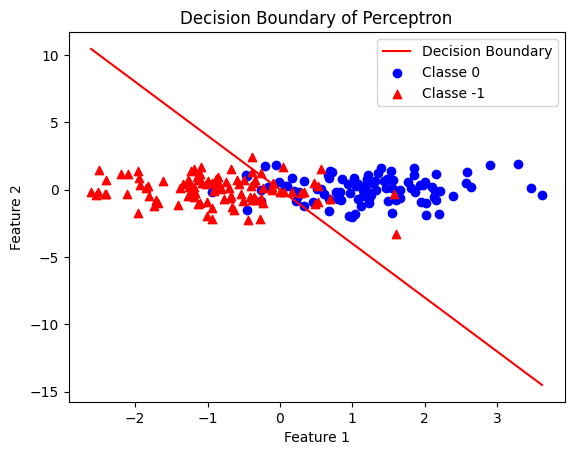

In [18]:
# Limite de decision
plot_decision_boundary(X_train, y_train, w)

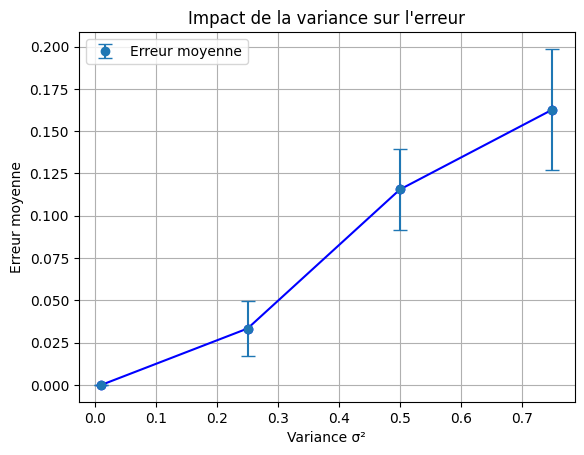

In [19]:
sigma_values = [0.01, 0.25, 0.5, 0.75]
# sigma_values = [0.01, 0.1, 0.5, 0.7]
nb_experiences = 30
errors_mean = []
errors_var = []

for sigma in sigma_values:
    errors_list = [] # Liste pour stocker les erreurs pour chaque expérience
    for i in range(nb_experiences):
        X_train, X_test, y_train, y_test = generate_dataset(sigma, sigma)

        # Entraînement du perceptron et récupération des erreurs
        w, errors = perceptron(X_train, y_train, lr=0.1, epochs=10)

        # Methode 1 pour calculer l'erreur
        errors_list.append(errors[-1] / len(X_train))  # Dernière erreur après convergence # Diviser par le nombre d'exemples pour normaliser

        # Methode 2 pour calculer l'erreur
        # accuracy = calculate_accuracy(X_train, y_train, w)
        # errors_list.append(1-accuracy)
        # print(f"Experience {i+1} : accuracy = {accuracy}")

    errors_mean.append(np.mean(errors_list))
    errors_var.append(np.var(errors_list))

# Plotter les barres d'erreur
plt.errorbar(sigma_values, errors_mean, yerr=np.sqrt(errors_var), fmt='o', capsize=5, label="Erreur moyenne")

# Tracer la courbe reliant les points
plt.plot(sigma_values, errors_mean, '-o', color='b')

# Personnalisation du graphique
plt.xlabel("Variance σ²")
plt.ylabel("Erreur moyenne")
plt.title("Impact de la variance sur l'erreur")
plt.legend()
plt.grid(True)

plt.show()
